# Figure 3 and partial Supplementary  Figure 2

![title](img/Fig3.png)

## Figure 3
Figure 3. Pacific zonally-integrated subsurface transport in (a) the Interior (solid purple: FOSI; dashed blue: LENS 10-member mean) and (b) WBC regions (purple: FOSI; blue: LENS 10-member mean). (c) Difference (LENS minus FOSI) in Interior (green) and WBC (brown). Shading indicates ±1 standard deviation (LENS 10-member spread). Grey bands mark 8°-15°S, encompassing Solomon Sea latitudes (~4°-11°S) where LENS interior transport is significantly reduced relative to FOSI (Sup. Fig. 2g). 
## Supplementary Figure 2 
Depth-integrated mean meridional transport (m2 s-1) of STC branches and subduction rate (m s-1) for the (top row) FOSI and (bottom row) LENS simulations. Shown are (a, d) subsurface transport, (b, e) surface transport, and (c, f) subduction rate. The thick red lines in (a) and (d) indicate the boundary between the WBC and Interior regions. The thick yellow lines in (a) and (d) indicate the western boundary of the WBC. Standard deviations across LENS ensemble members are shown in (g) subsurface transport, (h) surface transport, and (i) subduction rate. Difference (LENS minus FOSI) in mean (g) subsurface transport, (h) surface transport, and (i) subduction rate.  

### Imports

In [1]:
import pop_tools
import xarray as xr
import numpy as np
import cftime
import xesmf as xe
import cmocean
import matplotlib.pyplot as plt
import matplotlib.collections as mcollections
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
from scipy.signal import coherence, csd
from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks
from scipy.stats import linregress
import pandas as pd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import xesmf as xe
import pop_tools
import cftime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

import warnings
warnings.filterwarnings('ignore')  # Add this at the top of your script

/glade/u/apps/opt/conda/envs/npl-2025b/lib/python3.12/site-packages/pop_tools/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [2]:
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs
import stc_funcs as stcfuncs

### Functions

In [3]:
def regrid_SMYLE(ds, glat=1, glon=1): # from Jacob's notebook
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'ULONG': 'lon', 'ULAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

In [11]:
def cleaning_wbc_area(da):
    nan_mask = da.isnull()
    rightmost_nan_idx = xr.where(nan_mask, da.nlon, -1).max(dim='nlon')
    
    always_mask = da.nlon <= 3
    
    coast_threshold = 35
    is_coastal_boundary = rightmost_nan_idx <= coast_threshold
    conditional_mask = (da.nlon <= rightmost_nan_idx) & is_coastal_boundary
    
    final_mask = always_mask | conditional_mask
    
    da_cleaned = da.where(~final_mask)

    rightmost_nan_idx = xr.where(da.isnull(), da.nlon, -1).max(dim='nlon')
    mask_left = da.nlon <= rightmost_nan_idx
    da_core = da.where(~mask_left)
    
    coast_threshold = 35
    valid_coast = rightmost_nan_idx <= coast_threshold
    da_core = da_core.where(valid_coast, other=da)
    
    da_core[:, :5] = np.nan
    
    southern_mask = da.nlat < 60
    da_core = da_core.where(~(southern_mask & (da.nlon >= 5) & (da.nlon <= 9)), other=np.nan)
    
    # Final
    da_final = da_core
    rightmost_nan_idx = xr.where(da_final.isnull(), da_final.nlon, -1).max(dim='nlon')
    return da_final, rightmost_nan_idx

In [12]:
def find_wbc_boundary(transport_da, threshold=0.2):
    """
    Find the eastern boundary of the Western Boundary Current (WBC)
    using the rightmost point where the meridional transport gradient
    exceeds a threshold.
    
    Parameters
    ----------
    transport_da : xarray.DataArray
        Meridional transport array with dimensions (nlat, nlon).
        Units should be Sverdrups (Sv).
    threshold : float, default=0.2
        Gradient threshold in Sv per degree longitude.
        
    Returns
    -------
    rightmost_lons : numpy.ndarray
        Longitude of WBC eastern boundary at each latitude.
        NaN where no boundary is found.
    """
    # Calculate absolute zonal gradient
    ds_abs_diff = np.abs(transport_da.diff(dim='nlon'))
    
    # Get shape
    n_lats = ds_abs_diff.sizes['nlat']
    
    # Initialize arrays
    rightmost_indices = np.full(n_lats, np.nan)
    lon_coords = ds_abs_diff.nlon.values
    
    # Find rightmost strong gradient at each latitude
    for lat_idx in range(n_lats):
        grad_vals = ds_abs_diff.isel(nlat=lat_idx).values
        
        # Find where gradient exceeds threshold
        strong_indices = np.where(grad_vals > threshold)[0]
        
        if len(strong_indices) > 0:
            # Take the RIGHTMOST (largest index = easternmost)
            rightmost_indices[lat_idx] = strong_indices[-1]
    
    # Convert indices to longitudes
    rightmost_lons = np.full(n_lats, np.nan)
    
    for lat_idx, idx in enumerate(rightmost_indices):
        if not np.isnan(idx):
            rightmost_lons[lat_idx] = lon_coords[int(idx)]
    
    return rightmost_lons

In [13]:
def calc_wbc_transport(ds_integ, left_indx, right_indx):
    wbc_ts_list_fosi = []
    lat_val_list_fosi = []
    
    # ds_integ = fosi_subsurface_transport_ULONG_ULAT[:,20:65]
    for lat_indx in range(0, 100):
        wbc_ts = ds_integ[lat_indx, left_indx[lat_indx]:right_indx[lat_indx]].dropna(dim='nlon').integrate('ULONG').item()
        lat_val = ds_integ.ULAT[lat_indx, :].mean()
        lat_val_list_fosi.append(lat_val)
        wbc_ts_list_fosi.append(wbc_ts)
    return wbc_ts_list_fosi, lat_val_list_fosi

In [95]:
def find_int_bounds(da_int):
    rightmost_nan_idx = xr.where(da_int.isnull(), da_int.nlon, -1).max(dim='nlon') 
    first_nan_idx = xr.where(da_int.isnull(), da_int.nlon, 9999).min(dim='nlon')
    mask_contiguous = da_int.nlon < first_nan_idx
    da_clean = da_int.where(mask_contiguous)
    mask_final = (da_int.nlon < first_nan_idx) & (da_int.nlon < rightmost_nan_idx)
    da_clean = da_int.where(mask_final)
    leftmost_nan_int_idx = xr.where(da_clean.isnull(), da_clean.nlon, 9999).min(dim='nlon')
    left_int_indx = leftmost_nan_int_idx
    left_int_indx_data = left_int_indx.data
    return left_int_indx_data

In [96]:
def interpolate_wbc_bound(wbc_lons):
    arr = wbc_lons + 20
    nans = np.isnan(arr)
    x = np.arange(len(arr))
    arr_interp = np.interp(x[nans], x[~nans], arr[~nans])
    arr_full = arr.copy()
    arr_full[nans] = arr_interp
    arr_int = np.round(arr_full).astype(int)
    
    return arr_int

In [97]:
def calc_int_transport(ds_integ, arr_int, left_int_indx_data):
    int_ts_list_fosi = []
    lat_val_list_fosi = []
    
    # ds_integ = fosi_subsurface_transport_ULONG_ULAT
    # ds_integ = lens_subsurface_transport_ULONG_ULAT[0]
    for lat_indx in range(0,50):
        int_ts = ds_integ[lat_indx, arr_int[lat_indx]:].dropna(dim='nlon').integrate('ULONG').item()
        lat_val = ds_integ.ULAT[lat_indx, :].mean()
        lat_val_list_fosi.append(lat_val)
        int_ts_list_fosi.append(int_ts)
    
    for lat_indx in range(50,100):
        lat_indx_left = lat_indx-50
        int_ts = ds_integ[lat_indx, arr_int[lat_indx]:left_int_indx_data[lat_indx_left]].dropna(dim='nlon').integrate('ULONG').item()
        lat_val = ds_integ.ULAT[lat_indx, :].mean()
        lat_val_list_fosi.append(lat_val)
        int_ts_list_fosi.append(int_ts)
    return int_ts_list_fosi, lat_val_list_fosi

### Set up

In [4]:
# LENS for regridding purposes
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

#### FOSI set up
firstyear = 1959
lastyear = 2020
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)
fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]

### Plotting

In [5]:
CESMLENS_var = afuncs.LENS_for_regridding() # this is Area

In [6]:
ensemble_members = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49]

In [7]:
file_paths = [f'/glade/derecho/scratch/cassiacai/12032025_subsurface_transport_{i}.nc' for i in ensemble_members]
ds = xr.open_mfdataset(file_paths, combine='nested', concat_dim='ensemble', parallel=True)
ds.coords['ensemble'] = range(10)
subsurface_transport = ds['__xarray_dataarray_variable__'].compute()
lens_subsurface_transport_r = subsurface_transport#.mean(dim='ensemble')

In [8]:
fosi_subsurface_dr = xr.open_dataset(
    '/glade/derecho/scratch/cassiacai/12032025_fosi_subsurface_transport.nc').__xarray_dataarray_variable__

In [9]:
fosi_subsurface_r_dr = xr.DataArray(
    fosi_subsurface_dr.values if hasattr(fosi_subsurface_dr, 'values') else fosi_subsurface_dr,
    dims=['nlat', 'nlon'],  # Use your actual dimension names
    coords={
        'ULONG': lens_subsurface_transport_r.ULONG,
        'ULAT': lens_subsurface_transport_r.ULAT,
        'TLONG': lens_subsurface_transport_r.TLONG,
        'TLAT': lens_subsurface_transport_r.TLAT,
        'time': lens_subsurface_transport_r.time if hasattr(fosi_subsurface_dr, 'time') else existing_dataarray.time
    }
)

In [10]:
fosi_subsurface_transport_ULONG_ULAT = fosi_subsurface_r_dr.assign_coords(
    ULONG=(('nlat', 'nlon'), 
           lens_subsurface_transport_r['ULONG'].values),
    ULAT=(('nlat', 'nlon'), 
           lens_subsurface_transport_r['ULAT'].values))

lens_subsurface_transport_ULONG_ULAT = lens_subsurface_transport_r.assign_coords(
    ULONG=(('nlat', 'nlon'), 
           lens_subsurface_transport_r['ULONG'].values),
    ULAT=(('nlat', 'nlon'), 
           lens_subsurface_transport_r['ULAT'].values))

In [21]:
da = np.abs(fosi_subsurface_transport_ULONG_ULAT[:,20:60])
da_final, rightmost_nan_idx = cleaning_wbc_area(da)
wbc_lons_fosi = find_wbc_boundary(da_final, threshold=0.15)

left_indx = rightmost_nan_idx.data[:]
right_indx = np.asarray(wbc_lons_fosi[:].astype(int))

wbc_ts_list_fosi, lat_val_list_fosi = calc_wbc_transport(
    fosi_subsurface_transport_ULONG_ULAT[:,20:60], 
    left_indx, 
    right_indx)

da_int = np.abs(fosi_subsurface_transport_ULONG_ULAT[50:,60:])
left_int_indx_data = find_int_bounds(da_int)
arr_int = interpolate_wbc_bound(wbc_lons_fosi)
ds_integ = fosi_subsurface_transport_ULONG_ULAT[:,:]
int_ts_list_fosi, lat_val_list_fosi = calc_int_transport(ds_integ, arr_int, left_int_indx_data)

In [24]:
int_ts_ens = []
wbc_ts_ens = []
right_indx_as_lon_ls_ens = []
wbc_indx_as_lon_ls_ens = []
for ENS_MEMB in range(10):
    print(ENS_MEMB)
    da = np.abs(lens_subsurface_transport_ULONG_ULAT[ENS_MEMB, :,20:60])
    da_final_lens, rightmost_nan_idx_lens = cleaning_wbc_area(da)
    wbc_lons_lens = find_wbc_boundary(da_final_lens, threshold=0.15)
    
    left_indx_lens = rightmost_nan_idx_lens.data[:]
    right_indx_lens = np.asarray(wbc_lons_lens[:].astype(int))
    
    wbc_ts_list_lens, lat_val_list_lens = calc_wbc_transport(
        lens_subsurface_transport_ULONG_ULAT[ENS_MEMB, :,20:65], 
        left_indx_lens, right_indx_lens)
    
    da_int = np.abs(lens_subsurface_transport_ULONG_ULAT[ENS_MEMB, 50:,60:])
    left_int_indx_data = find_int_bounds(da_int)
    arr_int = interpolate_wbc_bound(wbc_lons_lens)
    ds_integ = lens_subsurface_transport_ULONG_ULAT[ENS_MEMB, :,:]
    int_ts_list_lens, lat_val_list_lens = calc_int_transport(ds_integ, arr_int, left_int_indx_data)
    int_ts_ens.append(int_ts_list_lens)
    wbc_ts_ens.append(wbc_ts_list_lens)

    right_indx_as_lon_ls = []
    wbc_indx_as_lon_ls = []
    for lat_indx in range(100):
        right_indx_plus_20 = rightmost_nan_idx_lens+20
        right_indx_as_lon = lens_subsurface_transport_ULONG_ULAT.ULONG[lat_indx, right_indx_plus_20[lat_indx]]
        wbc_indx_as_lon = lens_subsurface_transport_ULONG_ULAT.ULONG[lat_indx, arr_int[lat_indx]]
        right_indx_as_lon_ls.append(right_indx_as_lon.item())
        wbc_indx_as_lon_ls.append(wbc_indx_as_lon.item())
    right_indx_as_lon_ls_ens.append(right_indx_as_lon_ls)
    wbc_indx_as_lon_ls_ens.append(wbc_indx_as_lon_ls)

0
1
2
3
4
5
6
7
8
9


In [26]:
da = np.abs(lens_subsurface_transport_ULONG_ULAT[0, :,20:65])
da_final_lens, rightmost_nan_idx_lens = cleaning_wbc_area(da)
wbc_lons_lens = find_wbc_boundary(da_final_lens, threshold=0.15)

left_indx_lens = rightmost_nan_idx_lens.data[:]
right_indx_lens = np.asarray(wbc_lons_lens[:].astype(int))

wbc_ts_list_lens, lat_val_list_lens = calc_wbc_transport(
    lens_subsurface_transport_ULONG_ULAT[0, :,20:65], 
    left_indx_lens, right_indx_lens)

da_int = np.abs(lens_subsurface_transport_ULONG_ULAT[0, 50:,65:])
left_int_indx_data = find_int_bounds(da_int)
arr_int = interpolate_wbc_bound(wbc_lons_lens)
ds_integ = lens_subsurface_transport_ULONG_ULAT[0, :,:]
int_ts_list_lens, lat_val_list_lens = calc_int_transport(ds_integ, arr_int, left_int_indx_data)

In [27]:
right_indx_as_lon_ls = []
wbc_indx_as_lon_ls = []
for lat_indx in range(100):
    right_indx_plus_20 = rightmost_nan_idx_lens+20
    right_indx_as_lon = lens_subsurface_transport_ULONG_ULAT.ULONG[lat_indx, right_indx_plus_20[lat_indx]]
    wbc_indx_as_lon = lens_subsurface_transport_ULONG_ULAT.ULONG[lat_indx, arr_int[lat_indx]]
    right_indx_as_lon_ls.append(right_indx_as_lon)
    wbc_indx_as_lon_ls.append(wbc_indx_as_lon)

In [114]:
# diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.mean(dim='ensemble'))
diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.std(dim='ensemble'))

# diff_1deg_wzeros = regrid_SMYLE(fosi_subsurface_transport_ULONG_ULAT)

diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

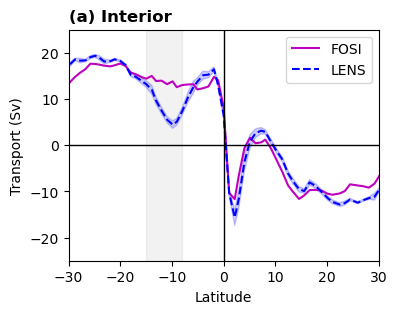

In [32]:
plt.figure(figsize=(4, 3))
plt.plot(lat_val_list_fosi, int_ts_list_fosi, c='m', label='FOSI')
plt.plot(lat_val_list_lens, np.asarray(int_ts_ens).mean(axis=0), c='blue', linestyle='dashed', label='LENS')

plt.fill_between(lat_val_list_fosi, 
                 np.asarray(int_ts_ens).mean(axis=0) - np.asarray(int_ts_ens).std(axis=0),
                 np.asarray(int_ts_ens).mean(axis=0) + np.asarray(int_ts_ens).std(axis=0),
                 alpha=0.2, color='blue')
plt.axhline(y=0, c='k', linewidth=1)
# plt.grid(c='k', linestyle='dashed', alpha=0.1, linewidth=0.5)
plt.xlim(-30, 30)
plt.ylim(-25, 25)
plt.axvline(x=0, c='k', linewidth=1)
plt.title('(a) Interior',loc='left', fontweight='bold',)
plt.ylabel('Transport (Sv)')
plt.xlabel('Latitude')
plt.legend()
plt.axvspan(-15, -8, alpha=0.1, color='gray', label='Southern Tropics')
plt.show()

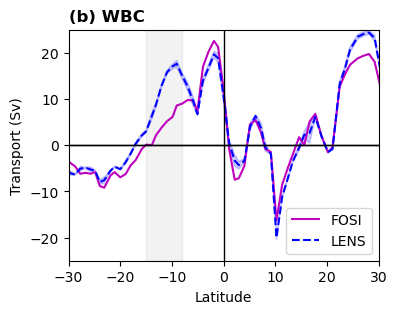

In [33]:
plt.figure(figsize=(4, 3))
plt.plot(lat_val_list_fosi, wbc_ts_list_fosi, c='m', label='FOSI')
plt.plot(lat_val_list_lens, np.asarray(wbc_ts_ens).mean(axis=0), c='blue', linestyle='dashed', label='LENS')

plt.fill_between(lat_val_list_fosi, 
                 np.asarray(wbc_ts_ens).mean(axis=0) - np.asarray(wbc_ts_ens).std(axis=0),
                 np.asarray(wbc_ts_ens).mean(axis=0) + np.asarray(wbc_ts_ens).std(axis=0),
                 alpha=0.2, color='blue')
plt.axhline(y=0, c='k', linewidth=1)

plt.axhline(y=0, c='k', linewidth=1)
# plt.grid(c='k', linestyle='dashed', alpha=0.1, linewidth=0.5)
plt.xlim(-30, 30)
plt.ylim(-25, 25)
plt.axvline(x=0, c='k', linewidth=1)
plt.title('(b) WBC',loc='left', fontweight='bold',)
plt.ylabel('Transport (Sv)')
plt.xlabel('Latitude')
plt.legend()
plt.axvspan(-15, -8, alpha=0.1, color='gray', label='Southern Tropics')
plt.show()

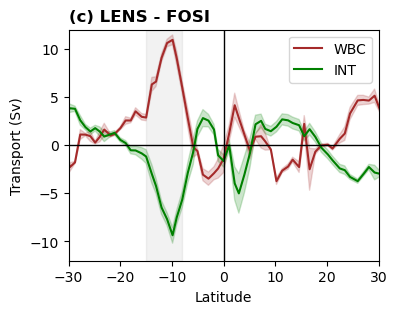

In [34]:
int_diff = np.asarray(int_ts_ens).mean(axis=0) - np.asarray(int_ts_list_fosi)
wbc_diff = np.asarray(wbc_ts_ens).mean(axis=0) - np.asarray(wbc_ts_list_fosi)

plt.figure(figsize=(4, 3))
plt.plot(lat_val_list_fosi, wbc_diff,c='brown', linewidth=1.5, label='WBC')
plt.plot(lat_val_list_fosi, int_diff,c='green', linewidth=1.5, label='INT')

plt.fill_between(lat_val_list_fosi, 
                 np.array(int_diff) - np.asarray(int_ts_ens).std(axis=0),
                 np.array(int_diff) + np.asarray(int_ts_ens).std(axis=0),
                 alpha=0.2, color='green')

plt.fill_between(lat_val_list_fosi, 
                 np.array(wbc_diff) - np.asarray(wbc_ts_ens).std(axis=0),
                 np.array(wbc_diff) + np.asarray(wbc_ts_ens).std(axis=0),
                 alpha=0.2, color='brown')

plt.axhline(y=0, c='k', linewidth=1)
# plt.grid(c='k', linestyle='dashed', alpha=0.1, linewidth=0.5)
plt.xlim(-30, 30)
plt.ylim(-12, 12)
plt.axvline(x=0, c='k', linewidth=1)
plt.title('(c) LENS - FOSI', loc='left', fontweight='bold',)
plt.ylabel('Transport (Sv)')
plt.xlabel('Latitude')
plt.legend()
plt.axvspan(-15, -8, alpha=0.1, color='gray', label='Southern Tropics')
plt.show()

In [37]:
da = np.abs(fosi_subsurface_transport_ULONG_ULAT[:,20:60])
da_final, rightmost_nan_idx = cleaning_wbc_area(da)
wbc_lons_fosi = find_wbc_boundary(da_final, threshold=0.15)

left_indx = rightmost_nan_idx.data[:]
right_indx = np.asarray(wbc_lons_fosi[:].astype(int))

wbc_ts_list_fosi, lat_val_list_fosi = calc_wbc_transport(
    fosi_subsurface_transport_ULONG_ULAT[:,20:60], 
    left_indx, 
    right_indx)

da_int = np.abs(fosi_subsurface_transport_ULONG_ULAT[50:,60:])
left_int_indx_data = find_int_bounds(da_int)
arr_int = interpolate_wbc_bound(wbc_lons_fosi)
ds_integ = fosi_subsurface_transport_ULONG_ULAT[:,:]
int_ts_list_fosi, lat_val_list_fosi = calc_int_transport(ds_integ, arr_int, left_int_indx_data)

In [ ]:
diff_1deg_wzeros = regrid_SMYLE(fosi_subsurface_transport_ULONG_ULAT)
diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)
regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

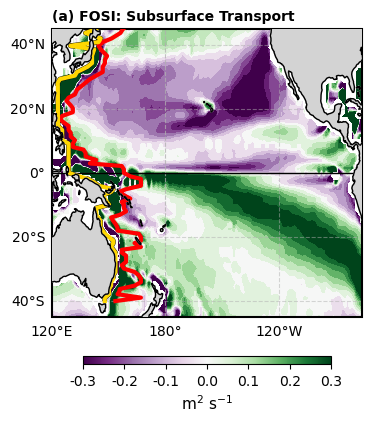

In [98]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-0.3, vmax=0.3, levels=14, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-0.3, 0.3))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label(r'm$^2$ s$^{-1}$', fontsize=11)
# tick_values = [-0.5, -0.25, 0., 0.25, 0.5]
tick_values = [-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
# tick_values = [-0.1, -0.05, 0, 0.05, 0.1]
# tick_values = [-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15] #[-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(a) FOSI: Subsurface Transport', fontsize=10, fontweight='bold', zorder=12, loc='left')

# right_indx_as_lon_ls = []
# wbc_indx_as_lon_ls = []

# plt.plot(wbc_ULONG_ls, 
#           lat_val_list_fosi, transform=ccrs.PlateCarree(), c='red', linewidth=1.5, linestyle='dashed')
# Plot a thicker background line first

mean_right = np.asarray(right_indx_as_lon_ls_ens).mean(axis=0)
mean_wbc = wbc_indx_as_lon_ls #np.asarray(wbc_indx_as_lon_ls_ens).mean(axis=0)

plt.plot(np.asarray(mean_right)[10:], 
         lat_val_list_fosi[10:], transform=ccrs.PlateCarree(), 
         c='black', linewidth=3.5, linestyle='dashed', zorder=19)

# Then plot the colored line on top
plt.plot(np.asarray(mean_right)[10:], 
         lat_val_list_fosi[10:], transform=ccrs.PlateCarree(), 
         c='gold', linewidth=3, zorder=50)

# Then plot the colored line on top
plt.plot(np.asarray(mean_wbc)[10:], 
         lat_val_list_fosi[10:], transform=ccrs.PlateCarree(), 
         c='red', linewidth=3, zorder=20)

plt.show()

In [ ]:
diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.mean(dim='ensemble'))
diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)
regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

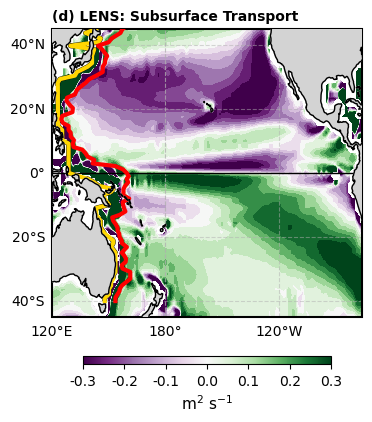

In [93]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='PRGn', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=-0.3, vmax=0.3, levels=14, alpha=1)

#### COLORBAR
density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-0.3, 0.3))
density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label(r'm$^2$ s$^{-1}$', fontsize=11)
# tick_values = [-0.5, -0.25, 0., 0.25, 0.5]
tick_values = [-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
# tick_values = [-0.1, -0.05, 0, 0.05, 0.1]
# tick_values = [-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15] #[-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(d) LENS: Subsurface Transport', fontsize=10, fontweight='bold', zorder=12, loc='left')

# right_indx_as_lon_ls = []
# wbc_indx_as_lon_ls = []

# plt.plot(wbc_ULONG_ls, 
#           lat_val_list_fosi, transform=ccrs.PlateCarree(), c='red', linewidth=1.5, linestyle='dashed')
# Plot a thicker background line first

mean_right = np.asarray(right_indx_as_lon_ls_ens).mean(axis=0)
mean_wbc = np.asarray(wbc_indx_as_lon_ls_ens).mean(axis=0)

plt.plot(np.asarray(mean_right)[10:], 
         lat_val_list_fosi[10:], transform=ccrs.PlateCarree(), 
         c='black', linewidth=3.5, linestyle='dashed', zorder=19)

# Then plot the colored line on top
plt.plot(np.asarray(mean_right)[10:], 
         lat_val_list_fosi[10:], transform=ccrs.PlateCarree(), 
         c='gold', linewidth=3, zorder=20)

# Then plot the colored line on top
plt.plot(np.asarray(mean_wbc)[10:], 
         lat_val_list_fosi[10:], transform=ccrs.PlateCarree(), 
         c='red', linewidth=3, zorder=20)

plt.show()

In [ ]:
diff_1deg_wzeros = regrid_SMYLE(lens_subsurface_transport_ULONG_ULAT.std(dim='ensemble'))
diff_1deg_var = diff_1deg_wzeros.where(diff_1deg_wzeros!=0, np.nan)
regridder = xe.Regridder(diff_1deg_var, CESMLENS_var[:,:], 'nearest_s2d', periodic=True)
regridded_diff = regridder(diff_1deg_var)

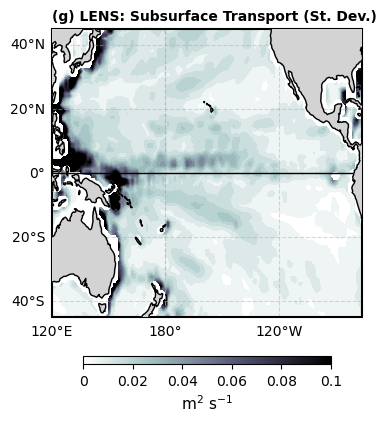

In [116]:
fig, ax = plt.subplots(figsize=(4, 5),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -45, 45], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# #### CONTOURF AND CONTOUR
contourf_plot = regridded_diff.plot.contourf(
    x='lon', y='lat', cmap='bone_r', add_colorbar=False, transform=ccrs.PlateCarree(),
    vmin=0, vmax=0.1, levels=21, alpha=1)

#### COLORBAR
# density_sm = plt.cm.ScalarMappable(cmap='PRGn', norm=plt.Normalize(-0.3, 0.3))
density_sm = plt.cm.ScalarMappable(cmap='bone_r', norm=plt.Normalize(-0, 0.1))

density_sm.set_array([])
density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
density_cbar.set_label(r'm$^2$ s$^{-1}$', fontsize=11)
# tick_values = [-0.05, -0.025, 0., 0.025, 0.05]
# tick_values = [-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
tick_values = [0, 0.02, 0.04, 0.06, 0.08, 0.10]
# tick_values = [-0.15, -0.1, -0.05, 0, 0.05, 0.1, 0.15] #[-0.3, -0.2, -0.1, 0., 0.1, 0.2, 0.3]
density_cbar.set_ticks(tick_values)
density_cbar.set_ticklabels([f'{x}' for x in tick_values]) 
density_cbar.ax.tick_params(labelsize=10)
plt.title('')
plt.title('(g) LENS: Subsurface Transport (St. Dev.)', fontsize=10, fontweight='bold', zorder=12, loc='left')

plt.show()